# Image Likelihood Explorer

Goal: understand what the Poisson image log-likelihood looks like as a function
of **all 8 cloud nuisance parameters in initial-condition space**
for N=1 and N>1 shots.

Parameters: `[mu_x0, mu_y0, mu_vx0, mu_vy0, sigma_x0, sigma_y0, sigma_vx0, sigma_vy0]`

No reparameterization — we keep the native initial-condition coordinates and let the
PSMAP structure (if any) break the apparent mu_x0/mu_vx0 degeneracy.

**Likelihood per shot:**
$$
\log L_i(\theta) = \log \frac{1}{K} \sum_{k=1}^{K}
  \exp\Bigl[
    \sum_{z\in\{Z0,Z100\}} \sum_{s,b} \bigl(
      n_{izsb}\,\log \lambda_{izsb}(\phi_k) - \lambda_{izsb}(\phi_k)
    \bigr)
  \Bigr]
$$
where $\phi_k$ are K equally spaced phases in $[0,2\pi)$.

**Multi-shot:** $\log L(\theta) = \sum_i \log L_i(\theta)$.

In [ ]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

REPO = os.path.abspath('..')
sys.path.insert(0, os.path.join(REPO, 'helpers'))
sys.path.insert(0, os.path.join(REPO, 'python-scripts'))
sys.path.insert(0, '/home/ndm33/local/aispy')

from helpers import ImageShotDataset
from aispy.psmap import load_psmap, PSMAPSurrogate
from profile_cloud_nuisances import SurrogatePixelACS, SemiAnalyticPixelACS

try:
    import cupy as cp
    from cupyx.scipy.special import logsumexp as cp_logsumexp
    xp = cp
    print('CuPy available — GPU enabled')
except ImportError:
    cp = None
    from scipy.special import logsumexp as np_logsumexp
    xp = np
    print('CuPy not found — CPU only')

def lse(a, axis=None):
    if xp is cp:
        return cp_logsumexp(a, axis=axis)
    from scipy.special import logsumexp; return logsumexp(a, axis=axis)


In [ ]:
RUN   = ('R20_N200_A100000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx100um_'
         'sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000')
DATA_ROOT  = os.path.join(REPO, 'data', RUN, 'run_000')
PSMAP_ROOT = os.path.join(REPO, 'output-files')

T_DET   = 3.8
BINS    = 32    # 32×32 = 1024 bins; each has ~2k GH evals (n_gh=20 → 400/bin × 1024)
N_GH    = 20   # Gauss-Hermite order per velocity dimension (400 evals/bin total)
N_THETA = 512

# SemiAnalyticPixelACS: exact Gaussian CDF spatial weights + 2D GH velocity integral.
# Never gives zero-bin predictions (no log(0) spikes), deterministic per-bin error.
MODEL_TYPE = f'SemiAnalyticPixelACS (n_gh={N_GH}, BINS={BINS})'

PRIOR_MU_POS  = np.array([0.0, 0.0])
PRIOR_MU_VEL  = np.array([0.0, 0.0])
PRIOR_SIG_POS = np.array([100e-6, 100e-6])
PRIOR_SIG_VEL = np.array([100e-6, 100e-6])
PRIOR_STD = np.array([10e-6, 10e-6,
                       10e-6, 10e-6,
                       10e-6, 10e-6,
                       10e-6, 10e-6])
PRIOR_MEAN = np.concatenate([PRIOR_MU_POS, PRIOR_MU_VEL, PRIOR_SIG_POS, PRIOR_SIG_VEL])

ds_z0   = ImageShotDataset(os.path.join(DATA_ROOT, 'Z0',   'data_IMG.h5'))
ds_z100 = ImageShotDataset(os.path.join(DATA_ROOT, 'Z100', 'data_IMG.h5'))
print(f'{ds_z0.n_shots} shots,  {ds_z0.res}×{ds_z0.res} px,  half_range={ds_z0.half_range*1e3:.1f} mm')

edges   = np.linspace(-ds_z0.half_range, ds_z0.half_range, BINS + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

print('Loading PSMAPs...', end=' ', flush=True)
psmap_z0   = load_psmap(os.path.join(PSMAP_ROOT, 'PSGRID4D_CONFOCAL_Z0.h5'))
psmap_z100 = load_psmap(os.path.join(PSMAP_ROOT, 'PSGRID4D_CONFOCAL_Z100.h5'))
print('done')


In [ ]:
print('Building evaluators...', end=' ', flush=True)
t0 = time.perf_counter()
sur_z0   = PSMAPSurrogate(psmap_z0,   T_DET, use_gpu=True)
sur_z100 = PSMAPSurrogate(psmap_z100, T_DET, use_gpu=True)
# QMC base (small N_QUAD — only needed to build GPU grid infrastructure)
_qmc_z0   = SurrogatePixelACS(sur_z0,   T_DET, edges, edges, n_quad=1024)
_qmc_z100 = SurrogatePixelACS(sur_z100, T_DET, edges, edges, n_quad=1024)
# Semi-analytic evaluators (reuse GPU grid from QMC, replace per-bin integral)
eval_z0   = SemiAnalyticPixelACS(_qmc_z0,   n_gh=N_GH)
eval_z100 = SemiAnalyticPixelACS(_qmc_z100, n_gh=N_GH)
print(f'done ({time.perf_counter()-t0:.1f}s)  '
      f'n_bins={eval_z0.n_bins}  evals/call={eval_z0.n_bins * eval_z0.n_v}')


In [ ]:
_count_cache = {}

def get_counts(i_shot):
    """Returns (ng0, ne0, ng1, ne1) — pixel counts on GPU."""
    if i_shot not in _count_cache:
        b = ds_z0.res // BINS
        img0 = np.asarray(ds_z0[i_shot],   dtype=np.float64)
        img1 = np.asarray(ds_z100[i_shot], dtype=np.float64)
        ng0 = xp.asarray(img0[0].reshape(BINS,b,BINS,b).sum(axis=(1,3)).ravel())
        ne0 = xp.asarray(img0[1].reshape(BINS,b,BINS,b).sum(axis=(1,3)).ravel())
        ng1 = xp.asarray(img1[0].reshape(BINS,b,BINS,b).sum(axis=(1,3)).ravel())
        ne1 = xp.asarray(img1[1].reshape(BINS,b,BINS,b).sum(axis=(1,3)).ravel())
        _count_cache[i_shot] = (ng0, ne0, ng1, ne1)
    return _count_cache[i_shot]


def _ll_ai(L, ng, ne, Ag, Ccg, Csg, Ae, Cce, Cse, c, s):
    lg = L * xp.maximum(Ag[None]+Ccg[None]*c[:,None]+Csg[None]*s[:,None], 1e-300)
    le = L * xp.maximum(Ae[None]+Cce[None]*c[:,None]+Cse[None]*s[:,None], 1e-300)
    return (ng[None]*xp.log(lg)-lg + ne[None]*xp.log(le)-le).sum(1)


def shot_logL(i_shot, theta_z0, theta_z100=None):
    """
    Full joint phi-marginalised logL.
    Z0 and Z100 are independent ensembles — always pass separate thetas.
    No delta_phi rotation: consistent with the profiling pipeline (_joint_logL).
    """
    if theta_z100 is None:
        theta_z100 = theta_z0
    theta_z0   = np.asarray(theta_z0,   dtype=float)
    theta_z100 = np.asarray(theta_z100, dtype=float)
    ng0, ne0, ng1, ne1 = get_counts(i_shot)
    A_g0,Cc_g0,Cs_g0,A_e0,Cc_e0,Cs_e0 = eval_z0.pixel_acs(theta_z0)
    A_g1,Cc_g1,Cs_g1,A_e1,Cc_e1,Cs_e1 = eval_z100.pixel_acs(theta_z100)
    L0 = float((ng0+ne0).sum()) / max(float((A_g0+A_e0).sum()), 1e-300)
    L1 = float((ng1+ne1).sum()) / max(float((A_g1+A_e1).sum()), 1e-300)
    phi = xp.linspace(0, 2*np.pi, N_THETA, endpoint=False)
    c, s = xp.cos(phi), xp.sin(phi)
    ll = (_ll_ai(L0,ng0,ne0,A_g0,Cc_g0,Cs_g0,A_e0,Cc_e0,Cs_e0,c,s) +
          _ll_ai(L1,ng1,ne1,A_g1,Cc_g1,Cs_g1,A_e1,Cc_e1,Cs_e1,c,s))
    return float(lse(ll) - np.log(N_THETA))


def make_z100_ctx(i_shot, theta_z100):
    """Pre-compute Z100 per-phi logL for fixed theta_z100 — halves sweep cost."""
    ng0, ne0, ng1, ne1 = get_counts(i_shot)
    A_g1,Cc_g1,Cs_g1,A_e1,Cc_e1,Cs_e1 = eval_z100.pixel_acs(theta_z100)
    L1 = float((ng1+ne1).sum()) / max(float((A_g1+A_e1).sum()), 1e-300)
    phi = xp.linspace(0, 2*np.pi, N_THETA, endpoint=False)
    c, s = xp.cos(phi), xp.sin(phi)
    ll_z100 = _ll_ai(L1,ng1,ne1,A_g1,Cc_g1,Cs_g1,A_e1,Cc_e1,Cs_e1,c,s)
    return {'ll_z100': ll_z100, 'ng0': ng0, 'ne0': ne0, 'c': c, 's': s}


def shot_logL_z0_sweep(theta_z0, ctx):
    """Fast logL for sweeping Z0 params with Z100 pre-computed."""
    theta_z0 = np.asarray(theta_z0, dtype=float)
    A_g0,Cc_g0,Cs_g0,A_e0,Cc_e0,Cs_e0 = eval_z0.pixel_acs(theta_z0)
    ng0, ne0 = ctx['ng0'], ctx['ne0']
    L0 = float((ng0+ne0).sum()) / max(float((A_g0+A_e0).sum()), 1e-300)
    c, s = ctx['c'], ctx['s']
    ll_z0 = _ll_ai(L0,ng0,ne0,A_g0,Cc_g0,Cs_g0,A_e0,Cc_e0,Cs_e0,c,s)
    return float(lse(ll_z0 + ctx['ll_z100']) - np.log(N_THETA))


def log_prior(theta):
    z = (np.asarray(theta) - PRIOR_MEAN) / PRIOR_STD
    return -0.5 * float(np.sum(z**2))

# ── timing check ────────────────────────────────────────────────────────────────
_m0 = ds_z0.meta(0);  _m1 = ds_z100.meta(0)
_th0 = np.array([_m0['mu_x0'],_m0['mu_y0'],_m0['mu_vx0'],_m0['mu_vy0'],
                 _m0['sigma_x'],_m0['sigma_y'],_m0['sigma_vx'],_m0['sigma_vy']])
_th1 = np.array([_m1['mu_x0'],_m1['mu_y0'],_m1['mu_vx0'],_m1['mu_vy0'],
                 _m1['sigma_x'],_m1['sigma_y'],_m1['sigma_vx'],_m1['sigma_vy']])

print('Timing shot_logL (full, 2 AIs)... ', end='', flush=True)
t0 = time.perf_counter()
_ll = shot_logL(0, _th0, _th1)
dt_full = time.perf_counter()-t0
print(f'{dt_full:.3f}s  logL={_ll:.2f}')

print('Timing shot_logL_z0_sweep (Z100 cached)... ', end='', flush=True)
_ctx = make_z100_ctx(0, _th1)
t0 = time.perf_counter()
for _ in range(10):
    shot_logL_z0_sweep(_th0, _ctx)
dt_fast = (time.perf_counter()-t0)/10
print(f'{dt_fast:.3f}s  (1D sweep ~{8*41*dt_fast:.0f}s, 2D ~{6*25**2*dt_fast/60:.1f}min)')


## 1D likelihood profiles — all 8 parameters, single shot

Each panel sweeps one parameter while holding all others at their true values.
$\Delta\log L < 0$ means the truth is preferred; a flat profile means no information.

In [24]:
SHOT = 0
m0 = ds_z0.meta(SHOT)
m1 = ds_z100.meta(SHOT)

def meta_to_theta(m):
    return np.array([m['mu_x0'], m['mu_y0'], m['mu_vx0'], m['mu_vy0'],
                     m['sigma_x'], m['sigma_y'], m['sigma_vx'], m['sigma_vy']])

theta_true      = meta_to_theta(m0)   # Z0 true cloud params (swept)
theta_z100_true = meta_to_theta(m1)   # Z100 true cloud params (fixed context)

PARAM_NAMES  = ['mu_x0', 'mu_y0', 'mu_vx0', 'mu_vy0',
                'sigma_x0', 'sigma_y0', 'sigma_vx0', 'sigma_vy0']
PARAM_UNITS  = ['µm',  'µm',  'µm/s', 'µm/s', 'µm', 'µm', 'µm/s', 'µm/s']
PARAM_SCALES = [1e-6,  1e-6,  1e-6,   1e-6,   1e-6, 1e-6, 1e-6,   1e-6  ]
_h5keys      = ['mu_x0','mu_y0','mu_vx0','mu_vy0','sigma_x','sigma_y','sigma_vx','sigma_vy']

print(f'True cloud params — shot {SHOT}:')
for name, unit, scale, k in zip(PARAM_NAMES, PARAM_UNITS, PARAM_SCALES, _h5keys):
    v0, v1 = float(m0[k])/scale, float(m1[k])/scale
    print(f'  {name:12s}  Z0={v0:+8.2f}  Z100={v1:+8.2f}  [{unit}]')

# ±3 × prior_std centred on prior mean
HALF_RANGES = 3.0 * PRIOR_STD
N_PTS_1D = 41
results_1d = {}

print('\nPre-computing Z100 context...', end=' ', flush=True)
t0 = time.perf_counter()
ctx = make_z100_ctx(SHOT, theta_z100_true)
print(f'done ({time.perf_counter()-t0:.1f}s)')

print('\nlogL at true theta...', end=' ', flush=True)
t0 = time.perf_counter()
logL_true    = shot_logL_z0_sweep(theta_true, ctx)
logpost_true = logL_true + log_prior(theta_true)
print(f'done ({time.perf_counter()-t0:.1f}s)  logL = {logL_true:.2f}')

print('\n1D sweeps (Z0 cloud params, Z100 fixed at true):')
for idx, (name, unit, scale, half_rng) in enumerate(
        zip(PARAM_NAMES, PARAM_UNITS, PARAM_SCALES, HALF_RANGES)):
    centre = PRIOR_MEAN[idx]
    vals = np.linspace(centre - half_rng, centre + half_rng, N_PTS_1D)
    lls  = []
    print(f'  {name:12s}...', end='', flush=True)
    t0 = time.perf_counter()
    for v in vals:
        th = theta_true.copy()
        th[idx] = v
        if any(th[k] <= 0 for k in [4, 5, 6, 7]):
            lls.append(-np.inf)
        else:
            lls.append(shot_logL_z0_sweep(th, ctx))
    lls = np.array(lls)
    peak_offset = vals[np.nanargmax(lls)] / scale - theta_true[idx] / scale
    print(f' {time.perf_counter()-t0:.0f}s  peak at true{peak_offset:+.2f} {unit}')
    results_1d[name] = (vals, lls)

print('Done.')


True cloud params — shot 0:
  mu_x0         Z0=   +6.15  Z100=  +20.70  [µm]
  mu_y0         Z0=  -15.20  Z100=  -27.13  [µm]
  mu_vx0        Z0=   +2.26  Z100=  -27.29  [µm/s]
  mu_vy0        Z0=   -9.32  Z100=  +17.79  [µm/s]
  sigma_x0      Z0= +100.31  Z100=  +94.38  [µm]
  sigma_y0      Z0=  +89.58  Z100=  +94.92  [µm]
  sigma_vx0     Z0=  +97.05  Z100=  +91.88  [µm/s]
  sigma_vy0     Z0= +103.74  Z100= +103.95  [µm/s]

Pre-computing Z100 context... done (0.1s)

logL at true theta... done (0.1s)  logL = 2062935252.24

1D sweeps (Z0 cloud params, Z100 fixed at true):
  mu_x0       ... 4s  peak at true-4.65 µm
  mu_y0       ... 4s  peak at true+7.70 µm
  mu_vx0      ... 4s  peak at true+0.74 µm/s
  mu_vy0      ... 4s  peak at true+0.32 µm/s
  sigma_x0    ... 4s  peak at true+29.69 µm
  sigma_y0    ... 4s  peak at true+23.92 µm
  sigma_vx0   ... 4s  peak at true+1.45 µm/s
  sigma_vy0   ... 4s  peak at true+0.76 µm/s
Done.


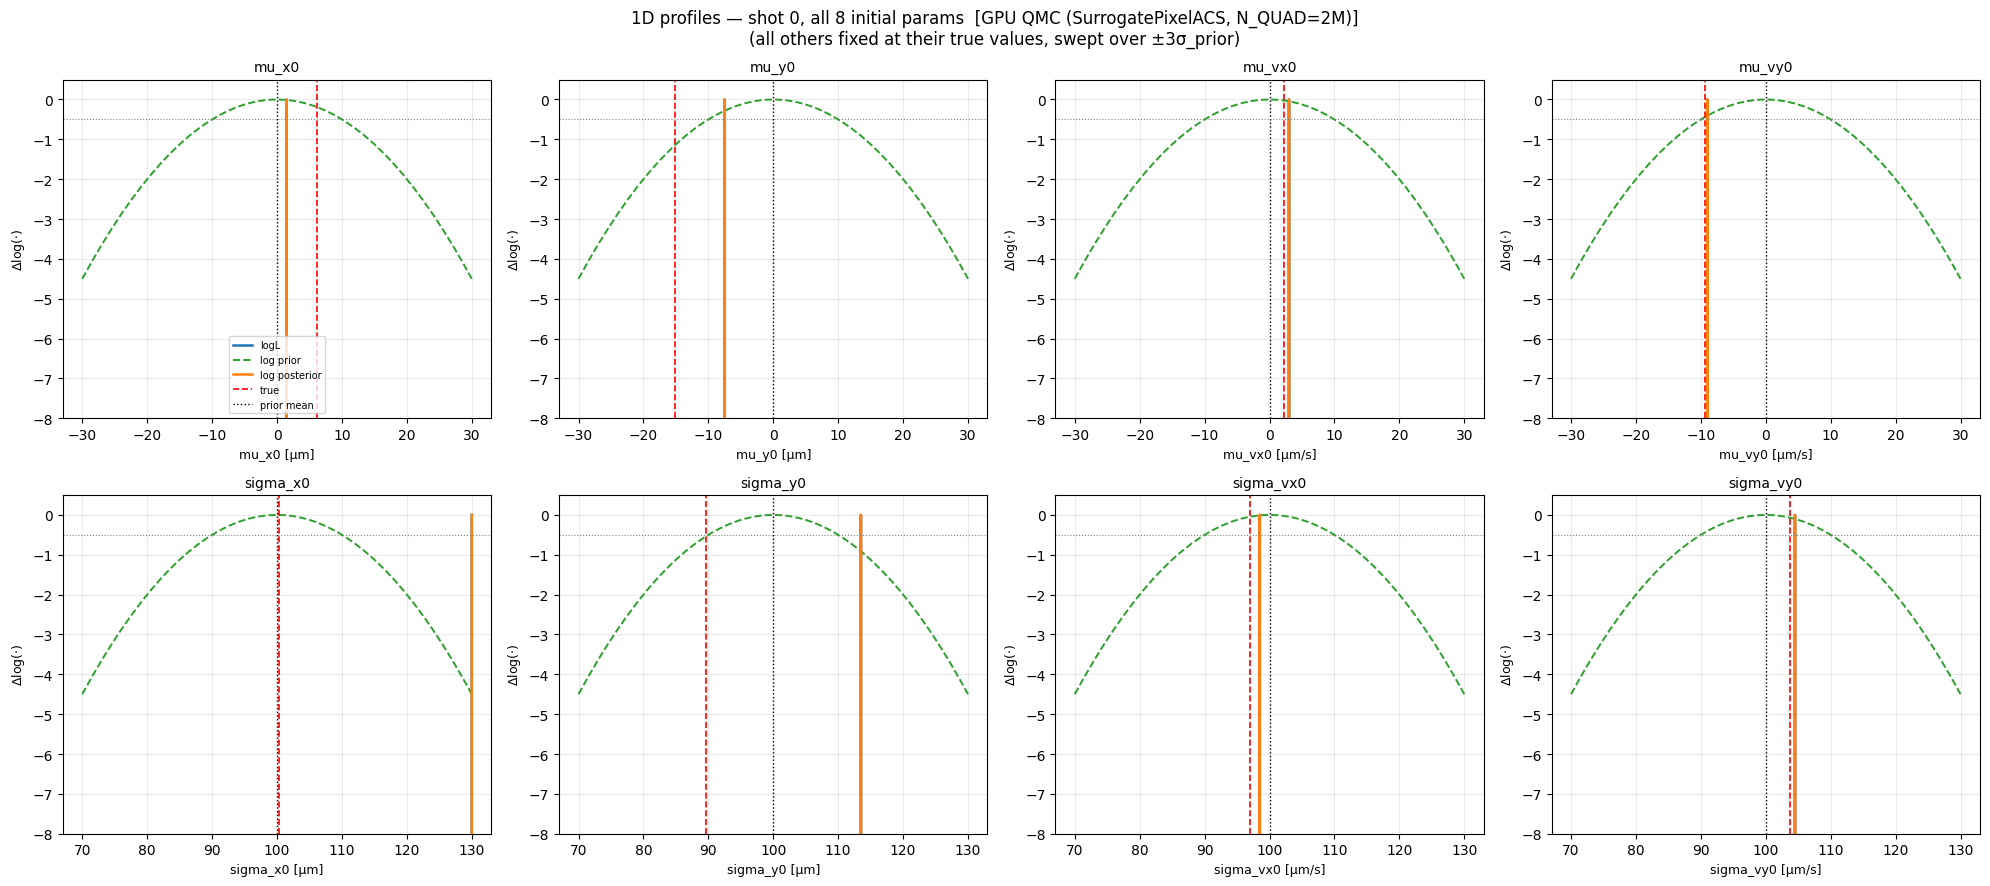

Saved results/ll_1d_all_params.pdf


In [25]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()

for idx, (name, unit, scale, ax) in enumerate(
        zip(PARAM_NAMES, PARAM_UNITS, PARAM_SCALES, axes)):
    vals, lls = results_1d[name]
    prior_vals = np.array([log_prior(np.where(np.arange(8)==idx, v, theta_true)) for v in vals])
    ll_norm    = lls - np.nanmax(lls)
    prior_norm = prior_vals - np.nanmax(prior_vals)
    post_norm  = (lls + prior_vals) - np.nanmax(lls + prior_vals)

    xs = vals / scale
    ax.plot(xs, ll_norm,    'C0-',  lw=1.8, label='logL')
    ax.plot(xs, prior_norm, 'C2--', lw=1.4, label='log prior')
    ax.plot(xs, post_norm,  'C1-',  lw=1.8, label='log posterior')
    ax.axvline(theta_true[idx] / scale, color='r',  ls='--', lw=1.2, label='true')
    ax.axvline(PRIOR_MEAN[idx] / scale, color='k',  ls=':',  lw=1.0, label='prior mean')
    ax.axhline(-0.5, color='gray', ls=':', lw=0.8)
    ax.set_xlabel(f'{name} [{unit}]', fontsize=9)
    ax.set_ylabel(r'$\Delta\log(\cdot)$', fontsize=9)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(-8, 0.5)
    ax.grid(True, alpha=0.25)
    if idx == 0:
        ax.legend(fontsize=7, loc='lower center')

fig.suptitle(f'1D profiles — shot {SHOT}, all 8 initial params  [{MODEL_TYPE}]\n'
             f'(all others fixed at their true values, swept over ±3σ_prior)',
             fontsize=12)
fig.tight_layout()
plt.savefig('../results/ll_1d_all_params.pdf', bbox_inches='tight')
plt.show()
print('Saved results/ll_1d_all_params.pdf')


## 2D slice likelihood — corner plot, single shot

Key pairs:
- **(mu_x0, mu_vx0)**: if the likelihood is flat along the ridge
  `mu_x0 + T·mu_vx0 = const`, the PSMAP gives no information to separate them.
  If the contours are diagonal (tilted away from that ridge), the PSMAP breaks
  the degeneracy via trajectory-dependent phase accumulation.
- **(sigma_x0, sigma_vx0)**: the main identifiability question for the spreads.
- **(mu_x0, sigma_x0)**, **(mu_vx0, sigma_vx0)**: cross-terms.

In [26]:
SWEEP_IDXS = [0, 2, 4, 6]  # mu_x0, mu_vx0, sigma_x0, sigma_vx0
N_PTS_2D = 25

def make_axis(idx):
    c = PRIOR_MEAN[idx]
    h = 3.0 * PRIOR_STD[idx]
    return np.linspace(c - h, c + h, N_PTS_2D)

pairs_axes = [(i, j, make_axis(i), make_axis(j))
              for ki, i in enumerate(SWEEP_IDXS)
              for j in SWEEP_IDXS[ki+1:]]

results_2d = []

for ix, iy, xs, ys in pairs_axes:
    ll_grid = np.full((N_PTS_2D, N_PTS_2D), np.nan)
    total = N_PTS_2D**2
    print(f'\n{PARAM_NAMES[ix]} vs {PARAM_NAMES[iy]}  ({total} evals)...')
    t0 = time.perf_counter(); done = 0
    for i, xv in enumerate(xs):
        for j, yv in enumerate(ys):
            th = theta_true.copy()
            th[ix] = xv; th[iy] = yv
            if all(th[k] > 0 for k in [4, 5, 6, 7]):
                ll_grid[i, j] = shot_logL_z0_sweep(th, ctx)
            done += 1
            if done % 50 == 0:
                el = time.perf_counter()-t0
                print(f'  {done}/{total}  {el:.0f}s  ETA={el/done*(total-done):.0f}s', end='\r')
    print(f'  done ({time.perf_counter()-t0:.0f}s)         ')
    results_2d.append((ix, iy, xs, ys, ll_grid))

print('All 2D sweeps done.')



mu_x0 vs mu_vx0  (625 evals)...


KeyboardInterrupt: 

In [ ]:
def prior_grid(ix, iy, xs, ys):
    g = np.empty((len(xs), len(ys)))
    for i, xv in enumerate(xs):
        for j, yv in enumerate(ys):
            th = theta_true.copy()
            th[ix] = xv; th[iy] = yv
            g[i, j] = log_prior(th)
    return g

def _plot_2d_panel(ax, xs, ys, ix, iy, values, title, vmin=None, vmax=None, cmap='viridis'):
    sx, sy = PARAM_SCALES[ix], PARAM_SCALES[iy]
    X, Y = np.meshgrid(xs/sx, ys/sy, indexing='ij')
    masked = np.where(np.isfinite(values), values, np.nan)
    masked = masked - np.nanmax(masked)
    if vmin is None: vmin = max(np.nanmin(masked), -30)
    if vmax is None: vmax = 0.0

    im = ax.pcolormesh(X, Y, masked, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
    if np.any(np.isfinite(masked)):
        levels = [l for l in [-9, -4.6, -2, -0.5] if l > vmin]
        if levels:
            try:
                cs = ax.contour(X, Y, masked, levels=levels,
                                colors='white', linewidths=0.8,
                                linestyles=[':', '-.', '--', '-'][:len(levels)])
                labels = {-9:'4σ', -4.6:'3σ', -2:'2σ', -0.5:'1σ'}
                ax.clabel(cs, fmt={l: labels[l] for l in levels},
                          inline=True, fontsize=7, colors='white')
            except Exception:
                pass
    ax.plot(theta_true[ix]/sx, theta_true[iy]/sy, 'r+', ms=12, mew=2.5, label='true')
    ax.plot(PRIOR_MEAN[ix]/sx, PRIOR_MEAN[iy]/sy, 'w^', ms=7,  mew=1.5, label='prior mean')
    ax.set_xlabel(f'{PARAM_NAMES[ix]} [{PARAM_UNITS[ix]}]', fontsize=9)
    ax.set_ylabel(f'{PARAM_NAMES[iy]} [{PARAM_UNITS[iy]}]', fontsize=9)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, label=r'$\Delta\log(\cdot)$', fraction=0.046, pad=0.04)
    return im

n_pairs = len(results_2d)
fig, axes = plt.subplots(n_pairs, 3, figsize=(15, 4.5 * n_pairs))
if n_pairs == 1:
    axes = axes[None, :]

for row, (ix, iy, xs, ys, ll_grid) in enumerate(results_2d):
    pg = prior_grid(ix, iy, xs, ys)
    post_grid = ll_grid + pg

    _plot_2d_panel(axes[row, 0], xs, ys, ix, iy, ll_grid,
                   f'logL: {PARAM_NAMES[ix]} vs {PARAM_NAMES[iy]}')
    _plot_2d_panel(axes[row, 1], xs, ys, ix, iy, pg,
                   f'log prior')
    _plot_2d_panel(axes[row, 2], xs, ys, ix, iy, post_grid,
                   f'log posterior (logL + prior)')
    axes[row, 0].legend(fontsize=7, loc='upper right')

fig.suptitle(f'2D corner slices — shot {SHOT}  [{MODEL_TYPE}]\n'
             f'Range ±3σ_prior centred on prior mean; other params at true values',
             fontsize=11)
fig.tight_layout()
plt.savefig('../results/ll_2d_corner.pdf', bbox_inches='tight')
plt.show()
print('Saved results/ll_2d_corner.pdf')


## Multi-shot profiles — does N matter?

Sweep the two hardest parameters (mu_vx0, sigma_vx0) for N = 1, 5, 10, 50 shots,
using the **per-shot true theta** for each shot (not a fixed population mean).
This is the correct oracle version: each shot's logL is evaluated at that shot's
own true cloud params, and we sweep one param at a time away from that truth.

In [ ]:
def shot_theta_z0(i):
    m = ds_z0.meta(i)
    return np.array([m['mu_x0'], m['mu_y0'], m['mu_vx0'], m['mu_vy0'],
                     m['sigma_x'], m['sigma_y'], m['sigma_vx'], m['sigma_vy']])

def shot_theta_z100(i):
    m = ds_z100.meta(i)
    return np.array([m['mu_x0'], m['mu_y0'], m['mu_vx0'], m['mu_vy0'],
                     m['sigma_x'], m['sigma_y'], m['sigma_vx'], m['sigma_vy']])

all_thetas_z0   = [shot_theta_z0(i)   for i in range(ds_z0.n_shots)]
all_thetas_z100 = [shot_theta_z100(i) for i in range(ds_z0.n_shots)]

def multi_shot_sweep(shot_indices, idx, deltas):
    lls = []
    for delta in deltas:
        total = 0.0
        for i in shot_indices:
            th = all_thetas_z0[i].copy()
            th[idx] += delta
            if any(th[k] <= 0 for k in [4, 5, 6, 7]):
                total = -np.inf; break
            total += shot_logL(i, th, all_thetas_z100[i])
        lls.append(total)
    return np.array(lls)

def multi_logL_true(shot_indices):
    return sum(shot_logL(i, all_thetas_z0[i], all_thetas_z100[i]) for i in shot_indices)

N_SHOTS_LIST = [1, 5, 10, 50]
SWEEP_PARAMS = [
    (2, 150e-6, 'mu_vx0', 'µm/s'),
    (6, 200e-6, 'sigma_vx0', 'µm/s'),
]
N_PTS_MULTI = 21
multi_results = {}

for (idx, half_rng, name, unit) in SWEEP_PARAMS:
    deltas = np.linspace(-half_rng, half_rng, N_PTS_MULTI)
    print(f'\nSweeping {name} ± {half_rng*1e6:.0f} {unit}...')
    for N in N_SHOTS_LIST:
        shots = list(range(N))
        print(f'  N={N:2d}...', end='', flush=True)
        t0 = time.perf_counter()
        lls = multi_shot_sweep(shots, idx, deltas)
        ll0 = multi_logL_true(shots)
        multi_results[(name, N)] = (deltas, lls - ll0)
        print(f' {time.perf_counter()-t0:.0f}s')

print('Done.')


In [ ]:
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
fig, axes = plt.subplots(1, len(SWEEP_PARAMS), figsize=(13, 5))

for ax, (idx, half_rng, name, unit) in zip(axes, SWEEP_PARAMS):
    for N, color in zip(N_SHOTS_LIST, colors):
        deltas, dll = multi_results[(name, N)]
        ax.plot(deltas*1e6, dll, color=color, lw=1.5, label=f'N={N}')
    ax.axvline(0, color='k', ls='--', lw=1, label='truth (Δ=0)')
    ax.axhline(-0.5, color='gray', ls=':', lw=1)
    ax.set_xlabel(f'Δ {name} [{unit}]', fontsize=12)
    ax.set_ylabel(r'$\Delta\log L$ (multi-shot)', fontsize=11)
    ax.set_title(name)
    ax.set_ylim(bottom=min(-5, ax.get_ylim()[0]))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Multi-shot profiles: N=1,5,10,50  (each shot at its own true theta + Δ)', fontsize=12)
fig.tight_layout()
plt.savefig('../results/ll_multishot_profiles.pdf', bbox_inches='tight')
plt.show()
print('Saved results/ll_multishot_profiles.pdf')